In [1]:
%pip install psycopg2 polars connectorx

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import pandas as pd
import polars as pl
from dotenv import load_dotenv, find_dotenv
import lightgbm as lgb
from sqlalchemy import create_engine
import psycopg2

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from scipy.stats import spearmanr

import matplotlib.pyplot as plt

import pickle
import json
from pathlib import Path
from datetime import datetime, timezone

In [3]:
def db_connection_string():
    load_dotenv(find_dotenv())

    host = 'localhost'
    port = 5433
    db = os.getenv('POSTGRES_DB')
    user = os.getenv('POSTGRES_USER')
    password = os.getenv('POSTGRES_PASSWORD')
    
    return f'postgresql://{user}:{password}@{host}:{port}/{db}'

In [4]:
def query_database(query: str):
    conn_str = db_connection_string()
    
    df = pl.read_database_uri(query=query, uri=conn_str)

    decimal_cols = [c for c, dtype in df.schema.items() if dtype == pl.Decimal]
    df = df.with_columns([pl.col(c).cast(pl.Float64) for c in decimal_cols])
    df_pandas = df.to_pandas()

    return df_pandas

In [5]:
query = """
    SELECT fix.season, feat.*
    FROM dev_ml.training_features feat
    JOIN dev_serving.dim_fixture fix
    ON feat.fixture_key = fix.fixture_key
"""

df_features = query_database(query)
df_features

,season,player_game_key,fixture_key,player_id,fpl_position,team_id,at_home,games_prior,appearance_rate,starting_rate,...,prev_season_influence_per_90,prev_season_creativity_per_90,prev_season_threat_per_90,prev_season_ict_index_per_90,prev_season_expected_goals_per_90,prev_season_expected_assists_per_90,prev_season_expected_goal_involvements_per_90,prev_season_expected_goal_chain_per_90,prev_season_expected_goal_buildup_per_90,league_avg_bps_this_season
0,2017,2017_100_128,2017_100,97299,DEF,43,False,9,1.000000,0.888889,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.619927
1,2017,2017_100_129,2017_100,108824,DEF,35,True,9,0.333333,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.619927
2,2017,2017_100_218,2017_100,15749,GKP,43,False,9,0.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.619927
3,2017,2017_100_219,2017_100,20310,GKP,43,False,9,0.333333,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.619927
4,2017,2017_100_220,2017_100,42593,DEF,43,False,9,0.888889,0.875000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.619927
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256055,2027,2027_9_559,2027_9,632794,MID,4,True,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.423868
256056,2027,2027_9_567,2027_9,470551,GKP,4,True,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.423868
256057,2027,2027_9_579,2027_9,445087,DEF,14,False,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.423868
256058,2027,2027_9_593,2027_9,463726,DEF,4,True,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.423868


In [6]:
query = """
    SELECT 
        player_game_key,
        total_points_recalculated
    FROM
        dev_serving.fact_player_game
"""

df_target = query_database(query)
df_target

,player_game_key,total_points_recalculated
0,2019_320_402,1.0
1,2019_186_241,1.0
2,2020_282_86,2.0
3,2020_42_62,0.0
4,2022_258_165,1.0
...,...,...
256055,2026_339_613,10.0
256056,2017_4_172,0.0
256057,2019_365_491,0.0
256058,2017_210_509,0.0


In [7]:
df_all = pd.merge(df_features, df_target, on='player_game_key', how='inner')
df_all

,season,player_game_key,fixture_key,player_id,fpl_position,team_id,at_home,games_prior,appearance_rate,starting_rate,...,prev_season_creativity_per_90,prev_season_threat_per_90,prev_season_ict_index_per_90,prev_season_expected_goals_per_90,prev_season_expected_assists_per_90,prev_season_expected_goal_involvements_per_90,prev_season_expected_goal_chain_per_90,prev_season_expected_goal_buildup_per_90,league_avg_bps_this_season,total_points_recalculated
0,2017,2017_100_128,2017_100,97299,DEF,43,False,9,1.000000,0.888889,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.619927,7.0
1,2017,2017_100_129,2017_100,108824,DEF,35,True,9,0.333333,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.619927,0.0
2,2017,2017_100_218,2017_100,15749,GKP,43,False,9,0.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.619927,0.0
3,2017,2017_100_219,2017_100,20310,GKP,43,False,9,0.333333,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.619927,0.0
4,2017,2017_100_220,2017_100,42593,DEF,43,False,9,0.888889,0.875000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.619927,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256055,2027,2027_9_559,2027_9,632794,MID,4,True,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.423868,1.0
256056,2027,2027_9_567,2027_9,470551,GKP,4,True,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.423868,1.0
256057,2027,2027_9_579,2027_9,445087,DEF,14,False,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.423868,1.0
256058,2027,2027_9_593,2027_9,463726,DEF,4,True,0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.423868,1.0


In [8]:
def preprocess_data(df, fit_categories=None, fit=False):
    # Drop identifier and descriptive columns
    id_cols = [col for col in df.columns if col.endswith('_id') or col.endswith('_key') or col == 'season']
    df = df.drop(columns=id_cols)

    # Convert boolean columns to integer
    bool_cols = df.select_dtypes(include=['bool']).columns.tolist()                
    for col in bool_cols:
        df[col] = df[col].astype('int')

    # Convert object columns to category type
    cat_cols = df.select_dtypes(include=['object']).columns.tolist()
    categories = {} if fit else fit_categories
    
    for col in cat_cols:
        if fit:
            df[col] = df[col].astype('category')
            categories[col] = df[col].cat.categories
        else:
            df[col] = pd.Categorical(df[col], categories=categories[col])

    # Rename target variable
    if 'total_points_recalculated' in df.columns:
        df.rename(columns={'total_points_recalculated': 'points'}, inplace=True)

    return df, (categories if fit else None)

In [9]:
train = df_all[df_all['season'] < 2025].copy()
test = df_all[df_all['season'] >= 2025].copy()

In [10]:
df_training, categories = preprocess_data(train, fit=True)
df_test, _ = preprocess_data(test, fit_categories=categories, fit=False)

X_train = df_training.drop(columns=['points'])
y_train = df_training['points']

X_test = df_test.drop(columns=['points'])
y_test = df_test['points']

In [11]:
def train_baseline_model(model, X_train, y_train):    
    model.fit(X_train, y_train)
    
    yhat_train = model.predict(X_train)
    mae = mean_absolute_error(y_train, yhat_train)
    mse = mean_squared_error(y_train, yhat_train)
    spearman = spearmanr(y_train, yhat_train).correlation
    
    print(f'Training MAE: {mae}')
    print(f'Training MSE: {mse}')
    print(f'Training Spearman: {spearman}')
    
    return model, yhat_train

In [12]:
def test_baseline_model(model, X_test, y_test):
    yhat_test = model.predict(X_test)

    mae = mean_absolute_error(y_test, yhat_test)
    mse = mean_squared_error(y_test, yhat_test)
    spearman = spearmanr(y_test, yhat_test).correlation
    
    print(f'Test MAE: {mae}')
    print(f'Test MSE: {mse}')
    print(f'Test Spearman: {spearman}')

    return yhat_test

In [13]:
lgbm = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

model_l2, yhat_train = train_baseline_model(lgbm, X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.084405 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 54076
[LightGBM] [Info] Number of data points in the train set: 196479, number of used features: 247
[LightGBM] [Info] Start training from score 1.325831
Training MAE: 1.0463351177141864
Training MSE: 3.52152467907449
Training Spearman: 0.7092014369198617


In [14]:
yhat_test = test_baseline_model(model_l2, X_test, y_test)

Test MAE: 1.0240821513846754
Test MSE: 3.782846554350013
Test Spearman: 0.7002562257836207


In [15]:
def get_summary(train_test, X, yhat):
    df = train_test.copy()
    df.loc[X.index, 'yhat'] = yhat

    query = """
        SELECT p.web_name, pg.player_game_key, pg.fixture_key, pg.player_id, pg.total_points_recalculated
        FROM dev_serving.fact_player_game pg
        JOIN dev_serving.dim_player p
        ON pg.player_id = p.player_id
    """

    df_info = query_database(query)

    df_summary = pd.merge(df_info, df[['player_game_key', 'yhat']], on='player_game_key', how='inner')

    return df_summary

In [16]:
get_summary(train, X_train, yhat_train).sort_values(by='yhat', ascending=False).head(50)

,web_name,player_game_key,fixture_key,player_id,total_points_recalculated,yhat
122990,Palmer,2024_325_362,2024_325,244851,26.0,18.331679
5156,Haaland,2024_39_355,2024_39,223094,20.0,16.240906
95686,Agüero,2018_264_257,2018_264,37572,21.0,14.517418
161141,De Bruyne,2020_377_215,2020_377,61366,19.0,13.865933
184833,Haaland,2023_49_318,2023_49,223094,17.0,13.449608
38715,M.Salah,2023_256_283,2023_256,118748,21.0,13.379935
105859,Kane,2017_374_403,2017_374,78830,17.0,13.125125
92381,M.Salah,2019_356_253,2019_356,118748,19.0,13.123739
95444,Agüero,2019_18_280,2019_18,37572,20.0,13.116922
159558,M.Salah,2024_194_308,2024_194,118748,16.0,12.999026


In [17]:
df_testing_summary = get_summary(test, X_test, yhat_test)
df_testing_summary.sort_values(by='yhat', ascending=False).head(50)

,web_name,player_game_key,fixture_key,player_id,total_points_recalculated,yhat
45590,Haaland,2025_9_351,2025_9,223094,7.0,9.962835
17438,Haaland,2026_7_430,2026_7,223094,13.0,9.548137
4972,M.Salah,2025_4_328,2025_4,118748,14.0,9.530994
39423,M.Salah,2026_1_381,2026_1,118748,8.0,9.507947
27608,Haaland,2027_8_411,2027_8,223094,2.0,9.288997
41345,B.Fernandes,2027_4_426,2027_4,141746,2.0,9.011964
52249,Haaland,2025_197_351,2025_197,223094,13.0,7.973843
45723,Saka,2025_2_17,2025_2,223340,12.0,7.817175
37361,Son,2025_19_503,2025_19,85971,16.0,7.792791
28541,Haaland,2025_298_351,2025_298,223094,0.0,7.727433


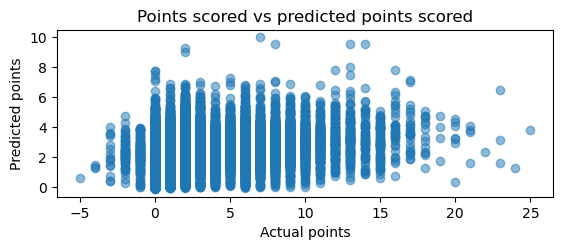

In [18]:
plt.scatter(y_test, yhat_test, alpha=0.5)
plt.xlabel('Actual points')
plt.ylabel('Predicted points')
plt.axis('scaled')
plt.title('Points scored vs predicted points scored')
plt.show()

In [19]:
def get_aggregates(df_summary):
    df_agg = df_summary.groupby(['player_id', 'web_name']).agg(
        pred_std=('yhat', 'std'),
        actual_std=('total_points_recalculated', 'std'),
        pred_mean=('yhat', 'mean'),
        actual_mean=('total_points_recalculated', 'mean'),
        n=('yhat', 'count')
    ).query('n >= 10')

    return df_agg

In [20]:
df_agg = get_aggregates(df_testing_summary)
df_agg.sort_values('actual_mean', ascending=False).head(15)

,,pred_std,actual_std,pred_mean,actual_mean,n
player_id,web_name,,,,,
118748,M.Salah,1.338068,5.288236,5.081665,6.144737,76
223094,Haaland,1.607403,4.872926,5.222873,5.662500,80
141746,B.Fernandes,1.133077,4.960540,4.176858,5.475000,80
446008,Mbeumo,0.847034,4.407111,4.374892,5.087500,80
178186,Bowen,0.851307,3.669696,4.449489,5.000000,76
437730,Semenyo,0.673106,3.919099,4.249884,4.787500,80
222531,Gibbs-White,0.688676,4.169206,3.626373,4.600000,80
244850,Rogers,0.805590,3.768436,3.614387,4.462500,80
244851,Palmer,1.542455,5.028463,3.996335,4.425000,80


### Notes
- Among top players, predicted mean is largely in the correct order compared to actual mean. However test predictions are consistently underpredicted.
- Predicted standard deviation is ~20% of actual values, this may be expected of a noisy target variable such as fpl points.

In [21]:
def residual_plot(df_agg):
    df_agg['residual'] = df_agg['pred_mean'] - df_agg['actual_mean']
    
    print(df_agg[['actual_mean', 'residual']].corr())
    
    plt.scatter(df_agg['actual_mean'], df_agg['residual'], alpha=0.5)
    plt.xlabel('Actual mean points')
    plt.ylabel('Predicted - Actual')
    plt.title('Actual mean points vs Residual')
    plt.show()

             actual_mean  residual
actual_mean     1.000000 -0.582733
residual       -0.582733  1.000000


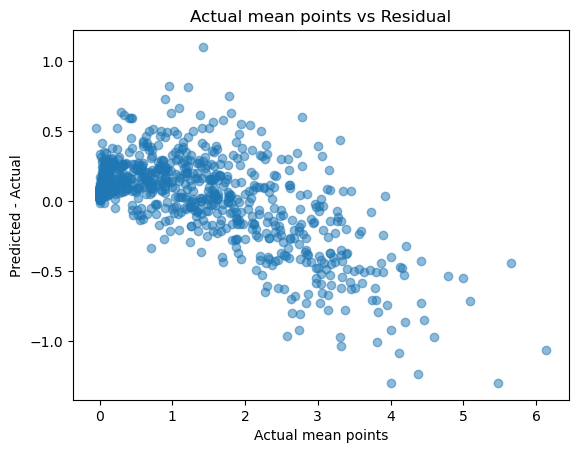

In [22]:
residual_plot(df_agg)

Strong positive correlation between how good a player is and how much the model underestimates them

In [23]:
model = lgb.LGBMRegressor(
    objective='regression_l1',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

model_l1, yhat_train_l1 = train_baseline_model(model, X_train, y_train)

yhat_test_l1 = test_baseline_model(model_l1, X_test, y_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.085429 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 54076
[LightGBM] [Info] Number of data points in the train set: 196479, number of used features: 247
Training MAE: 1.0094423596393696
Training MSE: 5.150390203077297
Training Spearman: 0.6718193412456709
Test MAE: 0.8843381339533138
Test MSE: 4.360934221950658
Test Spearman: 0.6862257243695169


In [24]:
df_testing_summary_l1 = get_summary(test, X_test, yhat_test_l1)
df_testing_summary_l1.sort_values(by='yhat', ascending=False).head(50)

,web_name,player_game_key,fixture_key,player_id,total_points_recalculated,yhat
32688,M.Salah,2025_246_328,2025_246,118748,8.0,4.108826
41752,M.Salah,2025_226_328,2025_226,118748,8.0,4.108446
11769,M.Salah,2025_275_328,2025_275,118748,15.0,4.085966
56340,M.Salah,2025_60_328,2025_60,118748,10.0,4.080768
24744,M.Salah,2025_315_328,2025_315,118748,6.0,4.059650
35757,M.Salah,2025_212_328,2025_212,118748,3.0,4.058555
27765,M.Salah,2025_297_328,2025_297,118748,3.0,4.037570
37672,M.Salah,2025_46_328,2025_46,118748,6.0,4.036775
50176,M.Salah,2025_327_328,2025_327,118748,3.0,4.017328
39486,M.Salah,2025_16_328,2025_16,118748,10.0,3.998743


In [25]:
df_agg_l1 = get_aggregates(df_testing_summary_l1)
df_agg_l1.sort_values('actual_mean', ascending=False).head(15)

,,pred_std,actual_std,pred_mean,actual_mean,n
player_id,web_name,,,,,
118748,M.Salah,1.030658,5.288236,2.960762,6.144737,76
223094,Haaland,0.655366,4.872926,2.496453,5.662500,80
141746,B.Fernandes,0.420185,4.960540,2.708856,5.475000,80
446008,Mbeumo,0.520418,4.407111,2.544572,5.087500,80
178186,Bowen,0.415986,3.669696,2.413752,5.000000,76
437730,Semenyo,0.295510,3.919099,2.524313,4.787500,80
222531,Gibbs-White,0.536319,4.169206,2.122817,4.600000,80
244850,Rogers,0.285787,3.768436,2.304126,4.462500,80
244851,Palmer,0.971147,5.028463,2.315679,4.425000,80


             actual_mean  residual
actual_mean     1.000000 -0.956039
residual       -0.956039  1.000000


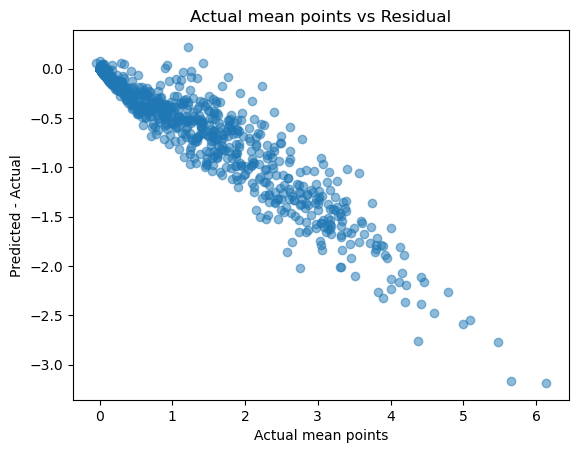

In [26]:
residual_plot(df_agg_l1)

L1 regression produces a more extreme correlation between player points average and underestimation.

In [27]:
query = """
    SELECT
        p.web_name,
        pg.player_game_key,
        pg.fixture_key,
        pg.player_id,
        pg.total_points_recalculated,
        avg(pg.total_points_recalculated) over last_5_games as yhat
    FROM dev_serving.fact_player_game pg
    JOIN dev_serving.dim_fixture f
    ON pg.fixture_key = f.fixture_key
    JOIN dev_serving.dim_player p
    ON pg.player_id = p.player_id
    WHERE f.season > 2024
    WINDOW last_5_games as (
        partition by pg.player_id
        order by kickoff_time
        rows between 5 preceding and 1 preceding
    )
"""

df_naive = query_database(query)
df_naive = df_naive.fillna(0)

In [28]:
mae = mean_absolute_error(df_naive['total_points_recalculated'], df_naive['yhat'])
mse = mean_squared_error(df_naive['total_points_recalculated'], df_naive['yhat'])
spearman = spearmanr(df_naive['total_points_recalculated'], df_naive['yhat']).correlation

print(f'Test MAE: {mae}')
print(f'Test MSE: {mse}')
print(f'Test Spearman: {spearman}')

Test MAE: 1.0656599139546263
Test MSE: 4.487531740170676
Test Spearman: 0.6857477713301819


             actual_mean  residual
actual_mean     1.000000 -0.159144
residual       -0.159144  1.000000


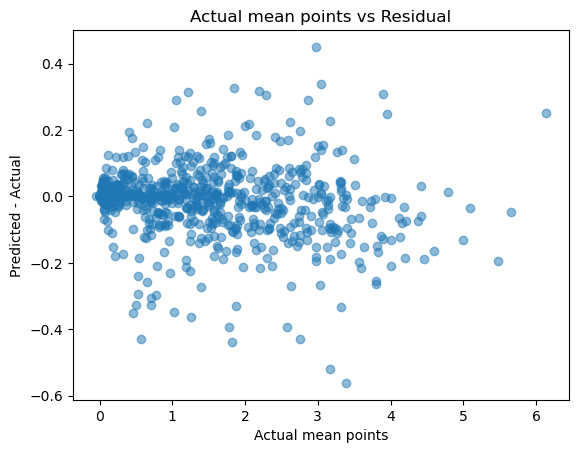

In [29]:
df_agg_naive = get_aggregates(df_naive)
residual_plot(df_agg_naive)

Underprediction of elite players does not reflect in a naive rolling 5 game average prediction

In [30]:
query = """
    SELECT
        p.web_name,
        pg.player_game_key,
        pg.fixture_key,
        pg.player_id,
        pg.total_points_recalculated,
        avg(pg.total_points_recalculated) over last_5_games as avg_points_last_5_games
    FROM dev_serving.fact_player_game pg
    JOIN dev_serving.dim_fixture f
    ON pg.fixture_key = f.fixture_key
    JOIN dev_serving.dim_player p
    ON pg.player_id = p.player_id
    WINDOW last_5_games as (
        partition by pg.player_id
        order by kickoff_time
        rows between 5 preceding and 1 preceding
    )
"""

df_aug = query_database(query)
df_aug = df_aug.fillna(0)

In [31]:
df_aug = pd.merge(df_all, df_aug[['player_game_key', 'avg_points_last_5_games']])

train_aug = df_aug[df_aug['season'] < 2025]
test_aug = df_aug[df_aug['season'] >= 2025]

In [32]:
df_training_aug, categories = preprocess_data(train_aug, fit=True)
df_test_aug, _ = preprocess_data(test_aug, fit_categories=categories, fit=False)

X_train_aug = df_training.drop(columns=['points'])
y_train_aug = df_training['points']

X_test_aug = df_test.drop(columns=['points'])
y_test_aug = df_test['points']

In [33]:
lgbm = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

model_aug, yhat_train = train_baseline_model(lgbm, X_train_aug, y_train_aug)
yhat_aug = test_baseline_model(model_aug, X_test_aug, y_test_aug)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.087368 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 54076
[LightGBM] [Info] Number of data points in the train set: 196479, number of used features: 247
[LightGBM] [Info] Start training from score 1.325831
Training MAE: 1.0463351177141864
Training MSE: 3.52152467907449
Training Spearman: 0.7092014369198617
Test MAE: 1.0240821513846754
Test MSE: 3.782846554350013
Test Spearman: 0.7002562257836207


In [34]:
aug_summary = get_summary(test_aug, X_test_aug, yhat_aug)
df_agg_aug = get_aggregates(aug_summary)
df_agg_aug.sort_values('actual_mean', ascending=False).head(15)

,,pred_std,actual_std,pred_mean,actual_mean,n
player_id,web_name,,,,,
118748,M.Salah,1.338068,5.288236,5.081665,6.144737,76
223094,Haaland,1.607403,4.872926,5.222873,5.662500,80
141746,B.Fernandes,1.133077,4.960540,4.176858,5.475000,80
446008,Mbeumo,0.847034,4.407111,4.374892,5.087500,80
178186,Bowen,0.851307,3.669696,4.449489,5.000000,76
437730,Semenyo,0.673106,3.919099,4.249884,4.787500,80
222531,Gibbs-White,0.688676,4.169206,3.626373,4.600000,80
244850,Rogers,0.805590,3.768436,3.614387,4.462500,80
244851,Palmer,1.542455,5.028463,3.996335,4.425000,80


             actual_mean  residual
actual_mean     1.000000 -0.582733
residual       -0.582733  1.000000


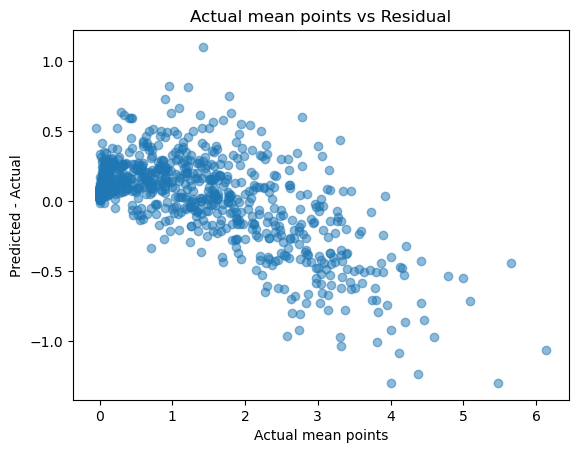

In [35]:
residual_plot(df_agg_aug)

Adding rolling average as a feature does not affect systemic underestimation of elite players

In [36]:
def add_gameweek(df):
    query = """
    select
    	f.canon_gameweek as gameweek,
        f.season,
    	pg.player_game_key
    from dev_serving.fact_player_game pg
    join dev_serving.dim_fixture f
    	on pg.fixture_key = f.fixture_key
    """

    df_gw = query_database(query)

    df_merge = pd.merge(df, df_gw, on='player_game_key', how='inner')

    return df_merge

In [37]:
def spearmanr_by_gw(df):
    """Compute spearman rank correlation between predicted and actual values, split by gameweek."""

    df_group = df[['player_game_key', 'total_points_recalculated', 'yhat', 'gameweek', 'season']]
    
    df_corr = df_group.groupby(['season', 'gameweek']).corr(method='spearman', numeric_only='true')

    r_by_gw = df_corr.xs('yhat', level=2)['total_points_recalculated']

    return r_by_gw.reset_index().rename(columns={'total_points_recalculated': 'spearman'})

In [38]:
df_gw_summary = add_gameweek(df_testing_summary)
df_gw_spearman = spearmanr_by_gw(df_gw_summary)

In [39]:
df_gw_naive = add_gameweek(df_naive)
df_naive_gw_spearman = spearmanr_by_gw(df_gw_naive)
df_spearman_by_gw = pd.merge(df_gw_spearman, df_naive_gw_spearman, on=['season', 'gameweek'])
df_spearman_by_gw.rename(columns={'spearman_x': 'test_spearman', 'spearman_y': 'naive_spearman'}).mean()

season            2025.575000
gameweek            18.650000
test_spearman        0.697667
naive_spearman       0.693695
dtype: float64

In [40]:
def get_predictions(model):
    query = """
        SELECT *
        FROM dev_ml.prediction_features
    """
    
    df_pred = query_database(query)
    df_pred_features, _ = preprocess_data(df_pred, fit_categories=categories)

    predictions = model_l2.predict(df_pred_features)

    df = df_pred.copy()
    df.loc[df_pred.index, 'xP'] = predictions

    query = """
        SELECT fixture_key, canon_gameweek
        FROM dev_serving.dim_fixture
    """
    
    df_fixture = query_database(query)
    
    query = """
        SELECT player_id, web_name
        FROM dev_serving.dim_player
    """
    
    df_player = query_database(query)

    df_pf = pd.merge(df, df_fixture, on='fixture_key')
    df_pfp = pd.merge(df_pf, df_player, on='player_id')
    df_pred_info = df_pfp[['fixture_key', 'player_id', 'fpl_position', 'web_name', 'canon_gameweek', 'xP']]

    return df_pred_info

In [41]:
df_predictions = get_predictions(model_l2)

In [42]:
query = 'canon_gameweek < 6'
df_predictions.query(query).groupby(['player_id', 'fpl_position', 'web_name'])['xP'].sum().sort_values(ascending=False).head(15)

player_id  fpl_position  web_name     
141746     MID           B.Fernandes      7.502104
223094     FWD           Haaland          6.375859
222531     MID           Gibbs-White      6.072511
177815     FWD           Calvert-Lewin    5.889108
466525     MID           Stach            5.802952
215413     MID           Dewsbury-Hall    5.564678
469142     DEF           Van Hecke        5.527579
513418     MID           Schade           5.335654
446008     MID           Mbeumo           5.154480
216646     FWD           Wissa            5.149485
209036     DEF           Guéhi            5.126252
244850     MID           Rogers           5.121671
514254     MID           Gomez            5.087550
440993     MID           Ndiaye           5.061200
215136     DEF           N.Williams       5.040136
Name: xP, dtype: float64

In [45]:
def save_model(model, model_name):
    # Save Model
    version = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S")
    model_dir = Path(f'../models/{model_name}/{version}')
    model_dir.mkdir(parents=True, exist_ok=True)    
    
    with open(model_dir / 'model.pkl', 'wb') as file:
        pickle.dump(model, file)

    # Write metadata
    meta = {
        'model_name': model_name,
        'model_version': version,
        'target': 'total_points_recalculated',
        'feature_columns': list(X_train.columns),
        'trained_through_season': int(train['season'].max()),
        'trained_at': datetime.now(timezone.utc).isoformat(),
        'framework': 'lightgbm',
        'framework_version': lgb.__version__,
        'training_params': {
            'objective'='regression',
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=31,
            random_state=42,
            n_jobs=-1
        }
    }

    with open(model_dir / 'meta.json', 'w') as file:
        json.dump(meta, file, indent=2)

In [46]:
save_model(model_l2, 'baseline_model')